In [1]:
from collections import OrderedDict
from pygom.model.transition import TransitionType, Transition
from pygom.model.simulate import SimulateOde
from time import perf_counter
import numpy as np

np.random.seed(1)

# Time considerations when using PyGOM with large numbers of parameters

In running the following global model (SEIR stratified by n countries, with possibility of infections being seeded between all paris of countries), it was noticed that building and running a PyGOM model can take a long time.

The equations:

$$\begin{aligned}
\frac{\mathrm{d} S_i}{\mathrm{d} t} &= -\lambda_i S_i\\
\frac{\mathrm{d} E_i}{\mathrm{d} t} &= \lambda_i S_i - \epsilon E_i \\
\frac{\mathrm{d} I_i}{\mathrm{d} t} &= \epsilon E_i - \gamma I_i\\
\frac{\mathrm{d} R_i}{\mathrm{d} t} &= \gamma I_i\\
\end{aligned}$$

where the force of infection per country is:

$$\begin{aligned}
\lambda_i &= \sum_{j=1}^{n} \beta_{ij} I_j\\
\end{aligned}$$

The number of parameters is thus $2+n^2$ ($\epsilon$ and $\gamma$ plus the $\beta$ matrix).
In this notebook, we'll be calling the matrix, $\beta$, the "connectivity matrix".

Below is the code necessary to build the above model in PyGOM:

In [ ]:
def SEIR_global_symbolic(n_countries):
    ''' 
    Build an SEIR PyGOM model stratified by country.

    In this implementation, the country connectivity matrix is taken to be symbolic, with the
    numeric values to be set later on after the model is set up
    
    Parameters:
    n _countries (int): Number of countries
    '''

    # Let country labels go from 1 to n_countries
    s = [str(i) for i in range(1, n_countries+1)]

    # container for connectivity matrix parameter names ([beta_c1c1, beta_c1c2, ...], [beta_c2c1, beta_c2c2, ...], ...)
    connectivity_matrix = []
    # container for forces of infection (lambda[i] = FOE for country i)
    lambda_list = []

    state_name = ["S", "E", "I", "R"]
    # container for country specific disease state compartments (S_c1, S_c2 ... , E_c1, E_c2 ... I_c1, I_c2 ... R_c1, R_c2 ...)
    states = OrderedDict.fromkeys(state_name, [])

    # Looping over country...
    for i in s:
        # (i) Define country specific disease state compartments
        for v in states:
            states[v] = states[v] + [str(v) + "_c" + i]

        # (ii) Add force of infection (which will be used to define the transitions below)
        lambda_temp='0'
        for j in s:
            connectivity_matrix += ['beta_c' + i + '_c' + j]
            lambda_temp += '+ beta_c' + i + '_c' + j + '*I_c' + j
        lambda_list.append(lambda_temp)

    # Get list of parameters:
    param_list = ['epsilon', 'gamma'] + connectivity_matrix

    # Get list of states
    state_list = []
    for v in states:
        state_list += states[v]

    # Get list of transitions
    transition = []
    for i in range(n_countries):
        transition += [Transition(origin=states['S'][i],
                                  destination=states['E'][i],
                                  equation='(' + lambda_list[i] + ')*' + states['S'][i],
                                  transition_type=TransitionType.T)]
        transition += [Transition(origin=states['E'][i],
                                  destination=states['I'][i],
                                  equation='epsilon*' + states['E'][i],
                                  transition_type=TransitionType.T)]
        transition += [Transition(origin=states['I'][i],
                                  destination=states['R'][i],
                                  equation='gamma*' + states['I'][i],
                                  transition_type=TransitionType.T)]

    # Build PyGOM model
    mod_obj = SimulateOde(state_list,
                          param_list,
                          transition=transition)
    
    return mod_obj

In the next code cell, we assume that values of the connectivity matrix are known and will not change.
We build a PyGOM model the same way as above, but now we have the numerical values in our expressions from the outset (skip to the next cell to see the model outputs and this should be clear).

In [ ]:
def SEIR_global_numeric(connectivity_matrix):
    ''' 
    Build an SEIR PyGOM model stratified by country.

    In this implementation, numerical values of the country connectivity matrix are provided so that
    they are effectively constants in the formulae.
    
    Parameters:
    connectivity_matrix (np.array of floats): beta_ij matrix (see equation in intro above)
    '''
    n_countries=connectivity_matrix.shape[0]

    # Let country labels go from 1 to n_countries
    s = [str(i) for i in range(1, n_countries+1)]

    # container for forces of infection (lambda[i] = FOE for country i)
    lambda_list = []

    state_name = ["S", "E", "I", "R"]
    # container for country specific disease state compartments (S_c1, S_c2 ... , E_c1, E_c2 ... I_c1, I_c2 ... R_c1, R_c2 ...)
    states = OrderedDict.fromkeys(state_name, [])

    # Looping over country...
    for i in s:
        # (i) Define country specific disease state compartments
        for v in states:
            states[v] = states[v] + [str(v) + "_c" + i]

        # (ii) Add force of infection (which will be used to define the transitions below)
        lambda_temp='0'
        for j in s:
            lambda_temp += '+ ' + str(connectivity_matrix[int(i)-1, int(j)-1]) + '*I_c' + j
        lambda_list.append(lambda_temp)

    # Get list of parameters:
    param_list = ['epsilon', 'gamma']

    # Get list of states
    state_list = []
    for v in states:
        state_list += states[v]

    # Get list of transitions
    transition = []
    for i in range(n_countries):
        transition += [Transition(origin=states['S'][i],
                                  destination=states['E'][i],
                                  equation='(' + lambda_list[i] + ')*' + states['S'][i],
                                  transition_type=TransitionType.T)]
        transition += [Transition(origin=states['E'][i],
                                  destination=states['I'][i],
                                  equation='epsilon*' + states['E'][i],
                                  transition_type=TransitionType.T)]
        transition += [Transition(origin=states['I'][i],
                                  destination=states['R'][i],
                                  equation='gamma*' + states['I'][i],
                                  transition_type=TransitionType.T)]

    # Build PyGOM model
    mod_obj = SimulateOde(state_list,
                          param_list,
                          transition=transition)
    
    return mod_obj

To make things clear, let's examine the ODE equations when we set up a model with 2 countries.

In the symbolic case we see all the $\beta$ terms are present.
(note, the reason for the letter c in the subscript is a fiddly thing to do with sympy, so don't be too distracted by them. Just read $\beta_{c1c2}$ as $\beta$ between country 1 and country 2)

In [5]:
mod=SEIR_global_symbolic(2)
mod.get_ode_eqn()

Matrix([
[               -S_c1*(I_c1*beta_c1_c1 + I_c2*beta_c1_c2)],
[               -S_c2*(I_c1*beta_c2_c1 + I_c2*beta_c2_c2)],
[-E_c1*epsilon + S_c1*(I_c1*beta_c1_c1 + I_c2*beta_c1_c2)],
[-E_c2*epsilon + S_c2*(I_c1*beta_c2_c1 + I_c2*beta_c2_c2)],
[                               E_c1*epsilon - I_c1*gamma],
[                               E_c2*epsilon - I_c2*gamma],
[                                              I_c1*gamma],
[                                              I_c2*gamma]])

Now let's see how the numerical model looks.
Notice that numbers now appear in place of the $\beta$ symbols.

In [6]:
connectivity_matrix=np.array([1,2,3,4]).reshape(2, 2)

mod=SEIR_global_numeric(connectivity_matrix)
mod.get_ode_eqn()

Matrix([
[                 -S_c1*(I_c1 + 2*I_c2)],
[               -S_c2*(3*I_c1 + 4*I_c2)],
[  -E_c1*epsilon + S_c1*(I_c1 + 2*I_c2)],
[-E_c2*epsilon + S_c2*(3*I_c1 + 4*I_c2)],
[             E_c1*epsilon - I_c1*gamma],
[             E_c2*epsilon - I_c2*gamma],
[                            I_c1*gamma],
[                            I_c2*gamma]])

We now test:

1) How long it takes to define the model in PyGOM

2) How long it takes to provide numerical values for the parameters

3) How long it takes to run the model (which actually means compiling it and integrating, the integration is actually much quicker, so read "run" as "compile")

And how these times vary when using the symbolic model, where the $n^2$ conenctivity parameters need to be set _after_ model definition versus the numerical case, where parameters are defined _at the point of_ model definition.

First we define some countries to perform these tests for us:

In [ ]:
def create_world(N_COUNTRIES):
    """
    Given a number of countries, N_COUNTRIES, create a world defined by the return values:
    pop_dist - A list of randomly generated populations
    travel matrix - An array of randomly generated travel patterns
    """
    # Say country pops are uniformly distributed between 100 and 200
    pop_dist = [np.random.randint(100, 200) for _ in range(N_COUNTRIES)]

    connectivity_matrix = np.zeros((N_COUNTRIES, N_COUNTRIES), dtype=int)
    for i_country in range(N_COUNTRIES):
        for j_country in range(N_COUNTRIES):
            # Say beta_ij is uniformly distributed between 1 and 10
            connectivity_matrix[i_country, j_country]=np.random.randint(1, 10)

    return pop_dist, connectivity_matrix

def initial_conditions(pop_dist):
    """
    Given the country populations, set all initially susceptible apart
    from E0 exposed in country with index 0.
    """
    N_COUNTRIES=len(pop_dist)
    E0=10   # 10 initially exposed

    # Set E0 exposed in country 0
    E0_by_country=N_COUNTRIES*[0]
    E0_by_country[0]+=E0

    S0_by_country=pop_dist
    S0_by_country[0]-=E0

    # Initial condition, x0=S0+E0+I0+R0
    x0=S0_by_country+E0_by_country+2*N_COUNTRIES*[0]

    return x0

def construct_params(connectivity_matrix):
    """
    Given the connectivity matrix construct parameter sets to feed to PyGOM in both dict and list form.
    """
    N_COUNTRIES=connectivity_matrix.shape[0]

    # Basic parameters
    # Whether the connectivity matrix is numeric or symbolic, we need
    # to specify these parameters in both cases
    basic_params_dict = {'epsilon':1/2.0, 'gamma':1/4.0}
    # In list form (need to be careful they are in the correct order)
    basic_params_list=list(basic_params_dict.values())
    # These basic parameters are sufficient for the numeric model.
    numeric_params=[basic_params_dict, basic_params_list]
    # We now need to add the extra parameters required for the symbolic model.

    # Container for connectivity params
    paramEval_connectivity={}
    for i_country in range(N_COUNTRIES):
        for j_country in range(N_COUNTRIES):
            paramEval_connectivity['beta_c' + str(i_country+1) + '_c' + str(j_country+1)]=connectivity_matrix[i_country, j_country]

    # Again, we provide parameter values in 2 forms:
    ## Dict with key:value = param_name:param_value
    paramEval_dict={'epsilon':1/2.0, 'gamma':1/4.0}
    paramEval_dict.update(paramEval_connectivity)
    ## List with param_values (in the correct order!)
    paramEval_list=list(paramEval_dict.values())
    symbolic_params=[paramEval_dict, paramEval_list]

    return numeric_params, symbolic_params

def sim_mod(type, connectivity_matrix, paramEval_dict, paramEval_list, x0, times, colwidth):
    """
    See how long different stages of model take from definition to simulation
    """
    N_COUNTRIES=connectivity_matrix.shape[0]

    # Build the PyGOM model
    t1=perf_counter()
    if type=="Numeric": 
        mod=SEIR_global_numeric(connectivity_matrix)
    elif type=="Symbolic":
        mod=SEIR_global_symbolic(N_COUNTRIES)
    t2=perf_counter()

    # Pass parameters as a list
    mod.parameters=paramEval_list
    t3=perf_counter()

    # Might be better to check new parameter time taken with a fresh model, not sure if presence of 
    # pre existing parameters might change anything.
    # if type=="Numeric": 
    #     mod=SEIR_global_numeric(N_COUNTRIES, travel_matrix)
    # elif type=="Symbolic":
    #     mod=SEIR_global_symbolic(N_COUNTRIES)
    # t4=perf_counter()

    # Pass parameters as a dict
    mod.parameters=paramEval_dict
    t5=perf_counter()

    # Initial conditions
    mod.initial_values = (np.array(x0, float), times[0])
    t6=perf_counter()

    # Deterministic simulation (compile sympy code + numerical integration, most time taken in compilation)
    solution = mod.solve_determ(times[1::], full_output=True)
    t7=perf_counter()

    print(f"{N_COUNTRIES:<{colwidth}} {type:<{colwidth}} {round(t2-t1,4):<{colwidth}} {round(t3-t2,4):<{colwidth}} {round(t5-t3,4):<{colwidth}} {round(t7-t6,4):<{colwidth}}")
    return [N_COUNTRIES, type, t2-t1, t3-t2, t5-t3, t7-t6]

def benchmark_scenarios(N_COUNTRIES, colwidth):
    """
    Build the relevant data for a given scenario and run the time checks
    """
    # Set the scene
    ## create the world
    pop_dist, connectivity_matrix = create_world(N_COUNTRIES)
    ## initial conditions
    x0=initial_conditions(pop_dist)
    ## parameters for 2 models in dict/list form
    numeric_params, symbolic_params = construct_params(connectivity_matrix)
    ## times to integrate over
    times = np.arange(start=0, stop=10, step=1)

    x1=sim_mod("Numeric", connectivity_matrix, numeric_params[0], numeric_params[1], x0, times, colwidth)
    x2=sim_mod("Symbolic", connectivity_matrix, symbolic_params[0], symbolic_params[1], x0, times, colwidth)

    return x1, x2

def sweep_scenarios(Ns, colwidth=25):
    """
    Run time checks for worlds with different numbers of countries
    """

    print(f"{'N countries':<{colwidth}} {'Travel param format':<{colwidth}} {'time build model':<{colwidth}} {'time parse list params':<{colwidth}} {'time parse dict params':<{colwidth}} {'time compile + run':<{colwidth}}")

    out=[]
    for N_COUNTRIES in Ns:
        d_out=benchmark_scenarios(N_COUNTRIES, colwidth)
        out.append(d_out[0])
        out.append(d_out[1])

    return out

In [8]:
out=sweep_scenarios([5, 10, 15, 20, 25, 30, 35, 40,
                     50, 60, 70, 80, 90, 100])

N countries               Travel param format       time build model          time parse list params    time parse dict params    time compile + run       
5                         Numeric                   0.002                     0.0001                    0.0001                    17.7609                  
5                         Symbolic                  0.0053                    0.0037                    0.006                     15.7245                  
10                        Numeric                   0.0024                    0.0001                    0.0001                    16.2466                  
10                        Symbolic                  0.0102                    0.0237                    0.0531                    18.9485                  
15                        Numeric                   0.0038                    0.0002                    0.0003                    17.0243                  
15                        Symbolic                  0.0188      

First, let's see how the time taken to compile scales with number of countries, $n$.

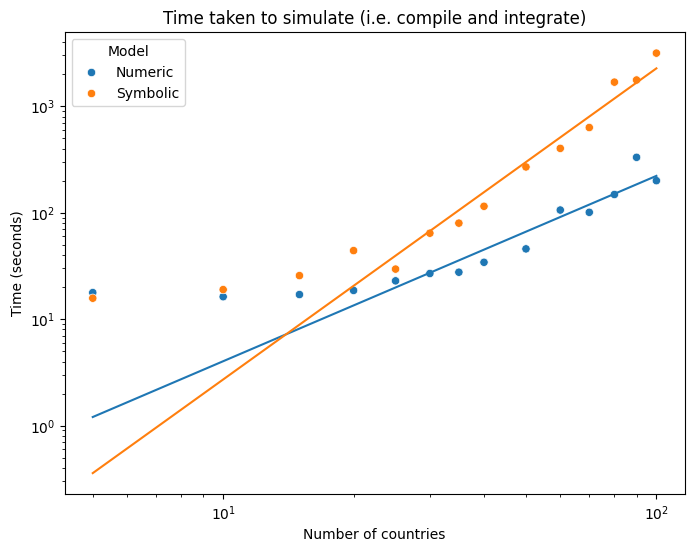

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.DataFrame(out, columns = ['N', 'Model', 'model', 'list_params', 'dict_params', 'simulate']) 

N_crit=4
df_num=df[df['Model']=="Numeric"]
slope_pre_num, intercept_pre_num = np.polyfit(np.log(df_num['N'].iloc[:N_crit]), np.log(df_num['simulate'].iloc[:N_crit]), 1)
slope_post_num, intercept_post_num = np.polyfit(np.log(df_num['N'].iloc[(N_crit-1):]), np.log(df_num['simulate'].iloc[(N_crit-1):]), 1)

df_sym=df[df['Model']=="Symbolic"]
slope_pre_sym, intercept_pre_sym = np.polyfit(np.log(df_sym['N'].iloc[:N_crit]), np.log(df_sym['simulate'].iloc[:N_crit]), 1)
slope_post_sym, intercept_post_sym = np.polyfit(np.log(df_sym['N'].iloc[(N_crit-1):]), np.log(df_sym['simulate'].iloc[(N_crit-1):]), 1)


plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='N', y='simulate', hue='Model')
plt.xscale('log')
plt.yscale('log')
plt.title("Time taken to simulate (i.e. compile and integrate)")
plt.xlabel("Number of countries")
plt.ylabel("Time (seconds)")
plt.plot(df['N'], np.exp(intercept_post_num)*np.array(df['N'])**slope_post_num)
plt.plot(df['N'], np.exp(intercept_post_sym)*np.array(df['N'])**slope_post_sym)
plt.show()

We would expect it to scale as number of parameters, $n^2$.
However, the scaling looks instead like (for the symbolic case)

In [20]:
print(f'Scaling for low n = {slope_pre_sym}')
print(f'Scaling for large n = {slope_post_sym}')

Scaling for low n = 0.6820631004525518
Scaling for large n = 2.9225048048821


Extrapolating this trend, this is an issue if we want to build a realistic (200) country model

In [28]:
print(f'Estimated time (hours) to build full global model (symbolic case) = {(np.exp(intercept_post_sym)*np.array(200)**slope_post_sym)/(60*60)}')

Estimated time (hours) to build full global model (symbolic case) = 4.7779102318119


The time taken for numeric connection parameters is around 2 as expected and is tolerably fast for the full global model:

In [27]:
print(f'Scaling for large n = {slope_post_num}')

Scaling for large n = 1.741234779317422


In [29]:
print(f'Estimated time (hours) to build full global model (numeric param case) = {(np.exp(intercept_post_num)*np.array(200)**slope_post_num)/(60*60)}')

Estimated time (hours) to build full global model (numeric param case) = 0.2059478182373808


In my experience it is actually faster than this.

We also examine the time taken in setting parameters, this scales as number of parameters to the 4th power (regardless of list or dict form).
This is very surprising, why is a 10,000 length list such a problem?
Anyway, this scaling is even more unfavourable than the compilation time.

Scaling = 3.9328252268829553


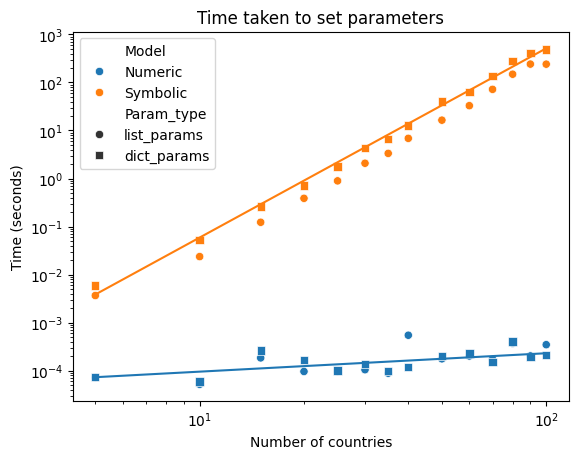

In [31]:
# Reshape the DataFrame to long format (melt)
df_melted = df.melt(id_vars=['N', 'Model'], value_vars=['list_params', 'dict_params'], var_name='Param_type', value_name='y')

dat=df_melted[ (df_melted['Model']=="Symbolic") & (df_melted['Param_type']=="dict_params")]
slope_sym, intercept_sym = np.polyfit(np.log(dat['N']), np.log(dat['y']), 1)

dat=df_melted[ (df_melted['Model']=="Numeric") & (df_melted['Param_type']=="dict_params")]
slope_num, intercept_num = np.polyfit(np.log(dat['N']), np.log(dat['y']), 1)

print(f'Scaling = {slope}')

sns.scatterplot(data=df_melted, x='N', y='y', hue='Model', style='Param_type', markers={"list_params": "o", "dict_params": "s"})
plt.plot(dat['N'], np.exp(intercept_num)*np.array(dat['N'])**slope_num)
plt.plot(dat['N'], np.exp(intercept_sym)*np.array(dat['N'])**slope_sym)
plt.xscale('log')
plt.yscale('log')
plt.title("Time taken to set parameters")
plt.xlabel("Number of countries")
plt.ylabel("Time (seconds)")
plt.show()

# Conclusions

The workaround thus far is to define the connection parameters from the start, so that we save a lot of time in the parameter setting (see above figure) and have more favourable scaling of compilation time when it comes to the simulations (see previous plot).